🧠 Hierarchical Clustering — Easy Explanation

Hierarchical Clustering = Groups banane ka ek tarika jisme clusters step-by-step bante hain.

Iske do tareeke hote hain:

⭐ 1. Agglomerative (Bottom–Up)

Sabse zyada use hota hai
Isme process neeche se upar chalti hai.

🧩 How it works?

Har data point ko apna alag cluster samjho.

Jinke beech distance sabse kam hoti hai, woh merge ho jaate hain.

Fir bache hue clusters me se dono sabse paas wale phir merge hote.

Ye process tab tak chalta hai jab tak 1 bada cluster nahi ban jata.

👉 Bilkul ais̱a jaise:
Har student ek cluster
Sabse close friends → ek group
Phir do groups close → ek bada group
Akhir me poori class → ek cluster

⭐ 2. Divisive (Top–Down)

Isme process upar se neeche chalti hai.

🧩 How it works?

Sabko ek single cluster maan lo.

Jinka behavior alag hai, unko alag group karo.

Fir groups ko break karte jao…

Jab tak chhote-chhote clusters nahi ban jaye.

👉 Jaise poori class ko ek group maan lo →
Phir group ke andar alag-alag students ki choice ke hisab se group tod do.

🪜 Hierarchical Clustering me kya special hai?

✔ Aapko clusters ka number pehle se decide nahi karna hotा
(KMeans me karna padta tha)

✔ Aap ek dendrogram bana kar dekh sakte ho
– Kitne clusters banane achhe rahenge
– Konsa cluster kis cluster se merge hua

✔ Clarity milti hai ki data kaise merge ho raha hai.

🌳 Dendrogram (Tree Diagram)

Ye ek tree-like graph hota hai jisme dikhata hai:

Kaun sa point kis se merge hua

Kis height (distance) pe merge hua

Kitne clusters honi chahiye

Agar dendrogram me horizontal line ko cut karoge →
jitni line cut hoti hain = utne clusters.

✅ Real Dataset Example — Hierarchical Clustering (Agglomerative)

Main Iris Dataset use kar raha hoon (machine learning ka sabse famous dataset).

Isme 3 flower types hain:

Setosa

Versicolour

Virginica

Aur 4 features:

sepal length

sepal width

petal length

petal width

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# 1️⃣ Dataset load
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 2️⃣ Features select (Petal Length & Petal Width)
# Easy visualization ke liye 2 columns le rahe hain
X = df[['petal length (cm)', 'petal width (cm)']]

# 3️⃣ Standardization (optional but good practice)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Hierarchical Clustering import
from sklearn.cluster import AgglomerativeClustering

# 5️⃣ Model banana – 3 clusters maan lete hain
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_scaled)

# 6️⃣ Labels ko dataframe me add karna
df['cluster'] = labels

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


📊 Dendrogram (Tree Diagram)

Ye sabse important hota hai hierarchical clustering me.

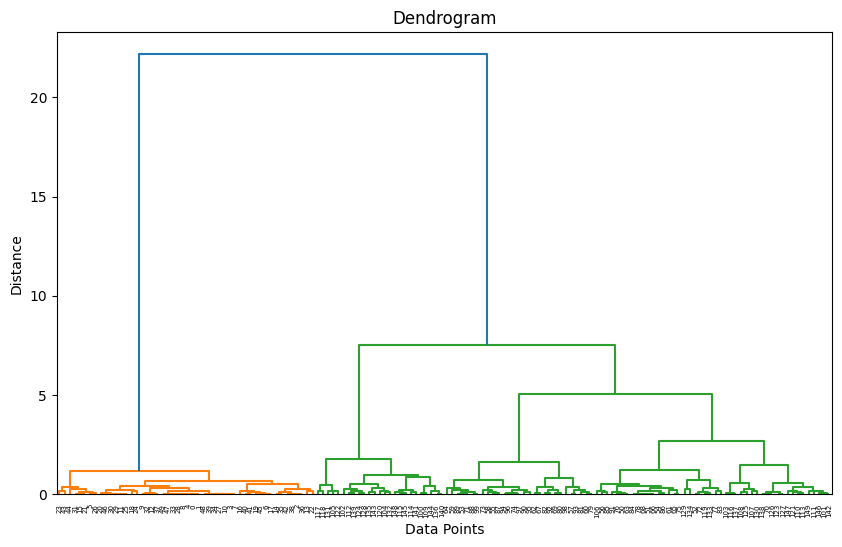

In [8]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


Clusters Plot (for visualization)

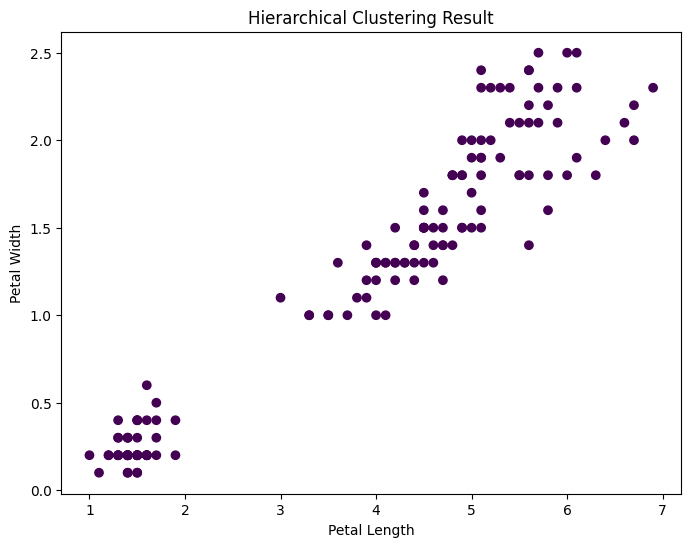

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(X.values[:,0], X.values[:,1], c=labels)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Hierarchical Clustering Result")
plt.show()


Linkage Kya Hota Hai?

Linkage = Do clusters kitne door hain, ye measure karne ka tarika

Hierarchical clustering me jab clusters merge hote hain, tab algorithm ko yeh decide karna hota hai ki:

👉 Kaunse do clusters pehle merge honge?
👉 Unke beech distance kaise calculate hogi?

Isko decide karne ke liye jo rule use hota hai, use linkage kehte hain.

⭐ Linkage  Types (Simple Example ke Saath)



1️⃣ Single Linkage

Dono clusters ke beech minimum distance dekhta hai.

👉 Real example:
Do groups me jo sabse paas wale do log hain, unka distance count hoga.

📌 Pros – clusters jaldi merge hote
📌 Cons – long chains ban jate → chaining problem

2️⃣ Complete Linkage

Maximum distance dekhta hai.

👉 Real example:
Do groups me jo sabse door wale do log hain, unka distance count hoga.

📌 Pros – compact clusters
📌 Cons – outliers ka effect zyada

3️⃣ Average Linkage

Dono clusters ke beech sabhi pairwise distances ka average leta hai.

👉 Real example:
Group 1 ke sab log vs Group 2 ke sab log
→ sab distances ka average

📌 Balanced result deta hai
📌 Kahi beech ka behaviour

4️⃣ Ward Linkage (Most used)

Clusters merge karte time variance ko minimum karta hai.
Ye try karta hai ki cluster andar se compact aur tight bane.

👉 Real example:
Merge tab hoga jab groups ko mila kar
sabse kam phailav (variance) aaye.

📌 Best results deta hai
📌 Scikit-learn ka default → linkage='ward'

⭐ Ek line me summary

Linkage	Distance ka Rule	Result
Single	Min distance	Lambi chain
Complete	Max distance	Tight clusters
Average	Average distance	Balanced
Ward	Variance kam	Best compact clusters
🤩 Super Easy Example

2 clusters:

Cluster A: {1, 2}
Cluster B: {8, 9}

Distances =

1 to 8 → 7

1 to 9 → 8

2 to 8 → 6

2 to 9 → 7

✔ Single linkage = min distance = 6

✔ Complete linkage = max distance = 8

✔ Average linkage = (7+8+6+7)/4 = 7

✔ Ward linkage = variance reduce karega